In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

In [18]:
data = load_breast_cancer(as_frame=True)

df = data.frame

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Check the size of the dataset

In [19]:
df.shape

(569, 31)

Look at the column names

In [20]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

Check the data types

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

Check missing values

In [22]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


Check duplicate rows

In [23]:
df.duplicated().sum()

np.int64(0)

Understand the target

In [24]:
df["diagnosis"] = df["target"].map({
    0: "Malignant",
    1: "Benign"
})

df["diagnosis"].value_counts()

,count
diagnosis,
Benign,357
Malignant,212


Our first simple visualization

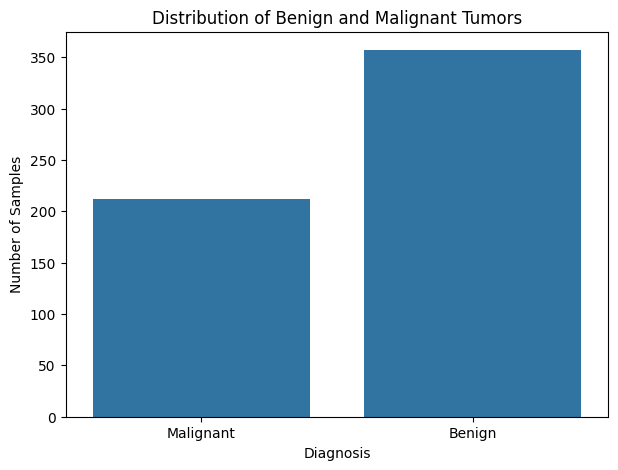

In [25]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="diagnosis"
)

plt.title("Distribution of Benign and Malignant Tumors")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

**Visualization 1: Tumor Radius Distribution**

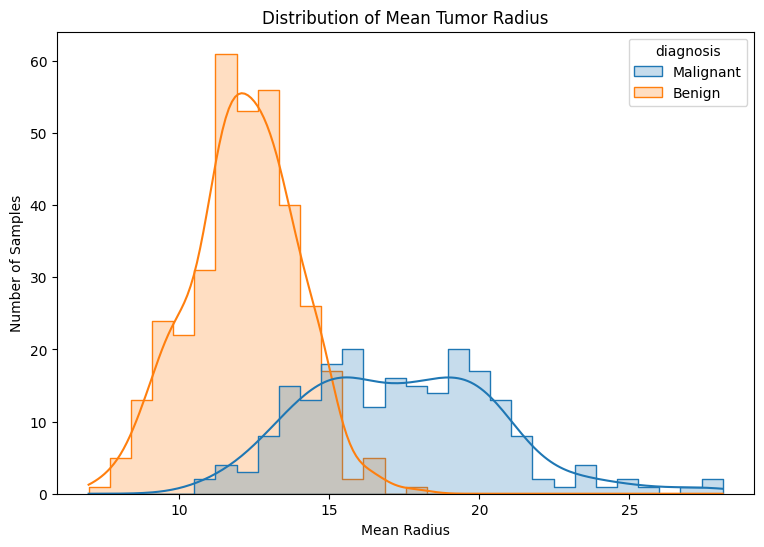

In [26]:
plt.figure(figsize=(9,6))

sns.histplot(
    data=df,
    x="mean radius",
    hue="diagnosis",
    kde=True,
    bins=30,
    element="step"
)

plt.title("Distribution of Mean Tumor Radius")
plt.xlabel("Mean Radius")
plt.ylabel("Number of Samples")

plt.show()

Visualization 3: Correlation Heatmap

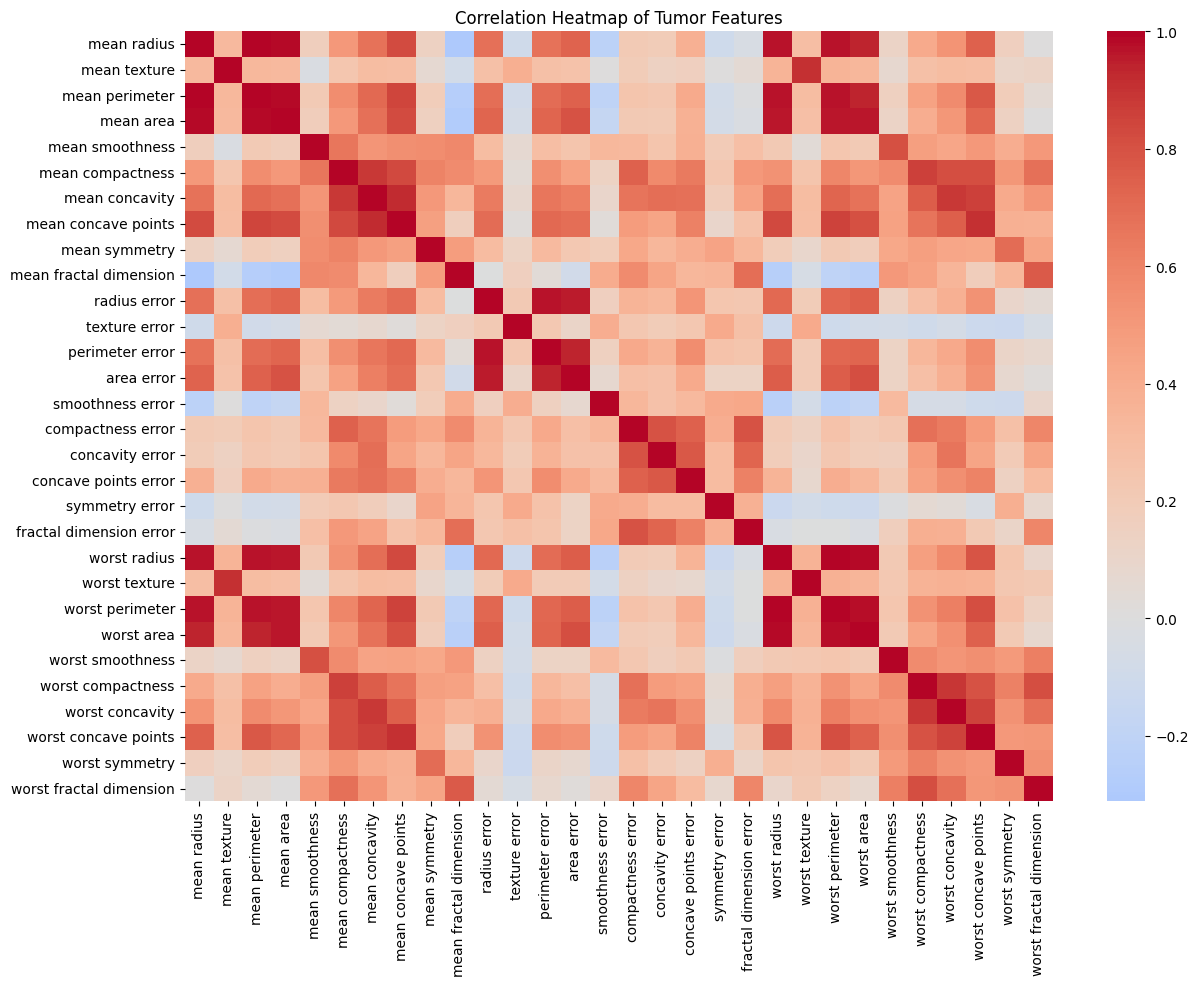

In [27]:
plt.figure(figsize=(14,10))

correlation = df.drop(columns=["target", "diagnosis"]).corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Tumor Features")

plt.show()

Visualization 4: Scatter Plot

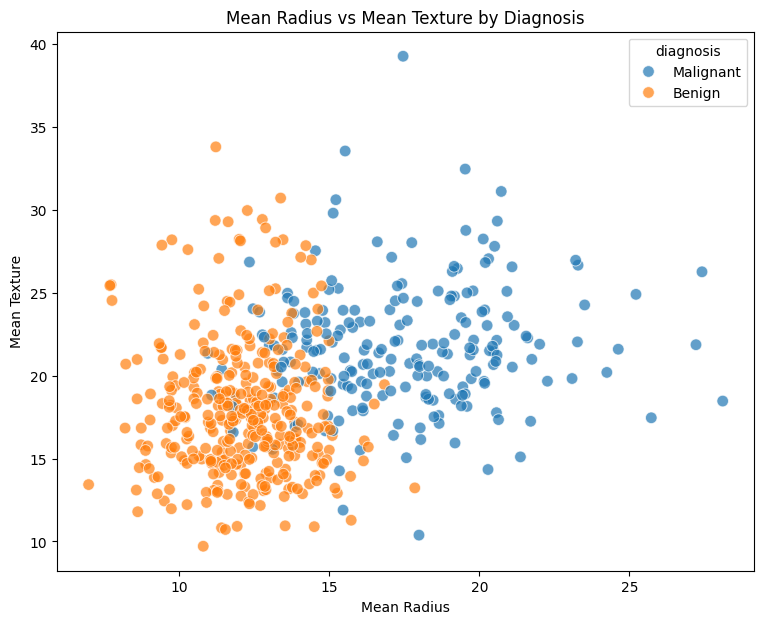

In [28]:
plt.figure(figsize=(9,7))

sns.scatterplot(
    data=df,
    x="mean radius",
    y="mean texture",
    hue="diagnosis",
    alpha=0.7,
    s=70
)

plt.title("Mean Radius vs Mean Texture by Diagnosis")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")

plt.show()

Visualization 5: Pair Plot

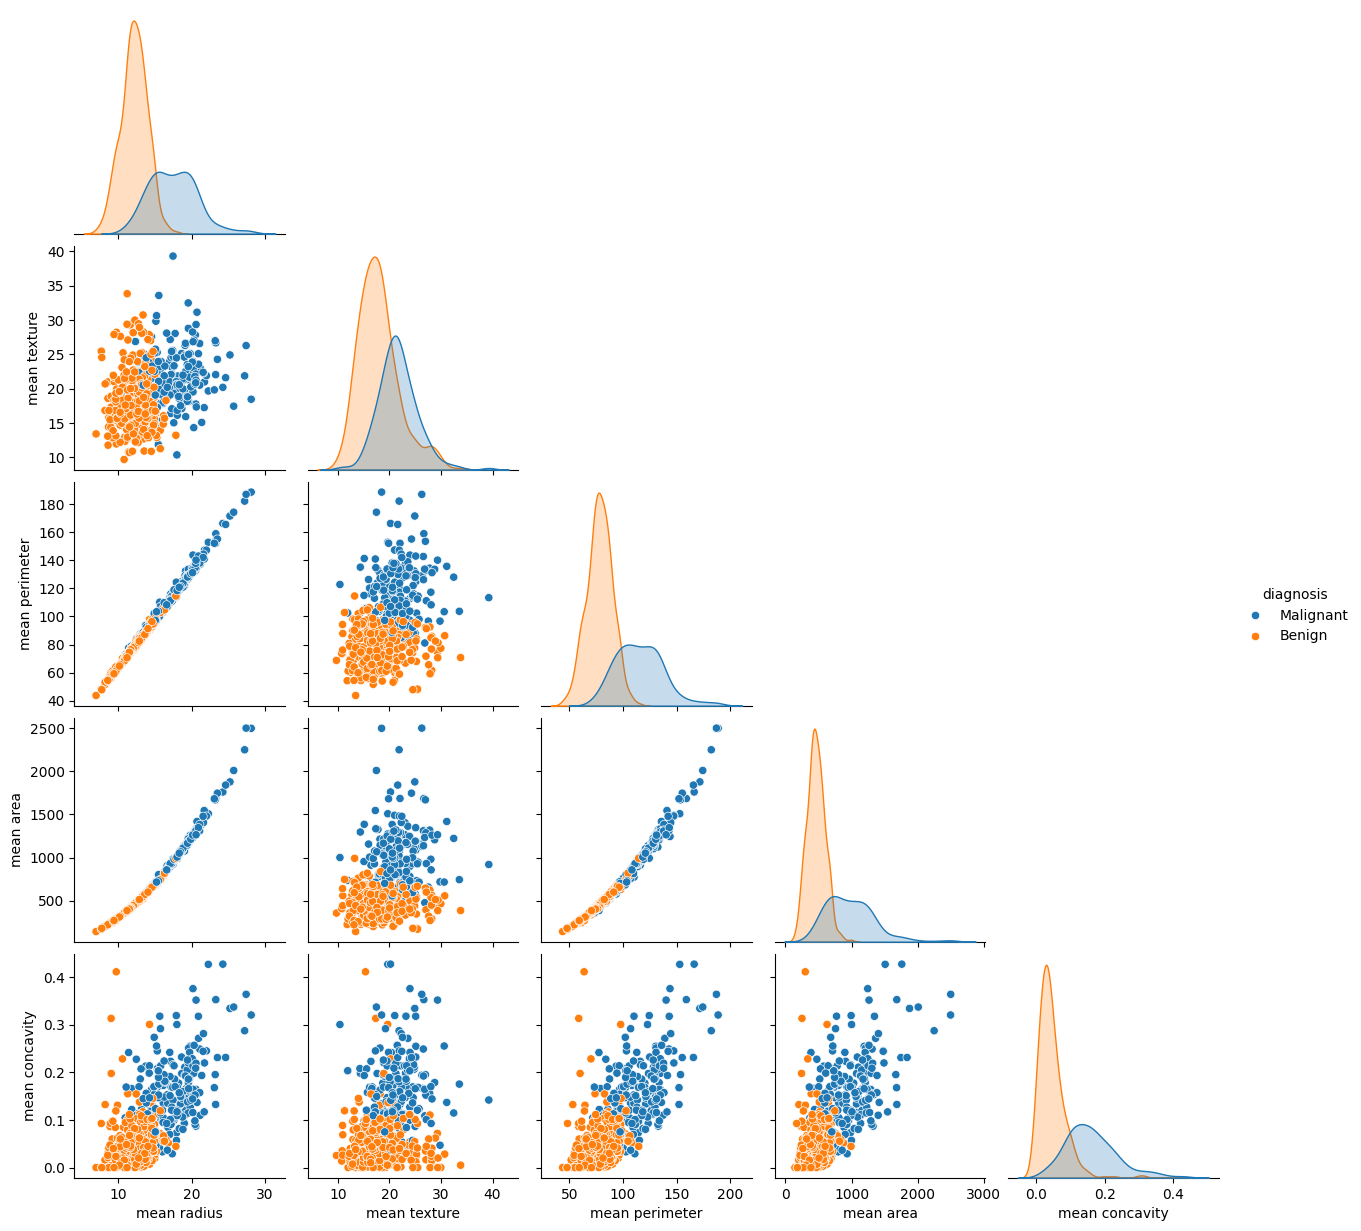

In [29]:
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean concavity",
    "diagnosis"
]
sns.pairplot(
    df[selected_features],
    hue="diagnosis",
    corner=True
)

plt.show()

numerical analysis

In [30]:
df.groupby("diagnosis")[
    ["mean radius", "mean texture", "mean perimeter",
     "mean area", "mean concavity"]
].mean()

,mean radius,mean texture,mean perimeter,mean area,mean concavity
diagnosis,,,,,
Benign,12.146524,17.914762,78.075406,462.790196,0.046058
Malignant,17.462830,21.604906,115.365377,978.376415,0.160775


Find the strongest correlations

In [31]:
corr_matrix = df.drop(
    columns=["target", "diagnosis"]
).corr()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

strong_correlations = (
    upper
    .stack()
    .sort_values(ascending=False)
)

strong_correlations.head(10)

,,0
mean radius,mean perimeter,0.997855
worst radius,worst perimeter,0.993708
mean radius,mean area,0.987357
mean perimeter,mean area,0.986507
worst radius,worst area,0.984015
worst perimeter,worst area,0.977578
radius error,perimeter error,0.972794
mean perimeter,worst perimeter,0.970387
mean radius,worst radius,0.969539
mean perimeter,worst radius,0.969476
